In [6]:
import pandas as pd
df=pd.read_csv(r"C:\Users\Risho\Downloads\6.Heart.csv")
print(df.shape)

(1025, 14)


In [ ]:
print(df.isnull().sum())
#no missing data
df.dropna() #if there is missing

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [7]:
#outlier detection
from scipy import stats
numerical=df[['age','trestbps','chol','thalach','oldpeak','ca','thal','target']]
zscore=stats.zscore(numerical)
outliers=(zscore>3).all(axis=1)
df=df[~outliers]
print(df.shape)

(1025, 14)


In [10]:
#normalization(minmax scaling for numeric field within a range)
from sklearn.preprocessing import MinMaxScaler
norm_columns=['age','trestbps','chol','thalach','oldpeak']
scaler=MinMaxScaler()
df[norm_columns]=scaler.fit_transform(df[norm_columns])
print(df.head())

        age  sex  cp  trestbps      chol  fbs  restecg   thalach  exang  \
0  0.479167    1   0  0.292453  0.196347    0        1  0.740458      0   
1  0.500000    1   0  0.433962  0.175799    1        0  0.641221      1   
2  0.854167    1   0  0.481132  0.109589    0        1  0.412214      1   
3  0.666667    1   0  0.509434  0.175799    0        1  0.687023      0   
4  0.687500    0   0  0.415094  0.383562    1        1  0.267176      0   

    oldpeak  slope  ca  thal  target  
0  0.161290      2   2     3       0  
1  0.500000      0   0     3       0  
2  0.419355      0   0     3       0  
3  0.000000      2   1     3       0  
4  0.306452      1   3     2       0  


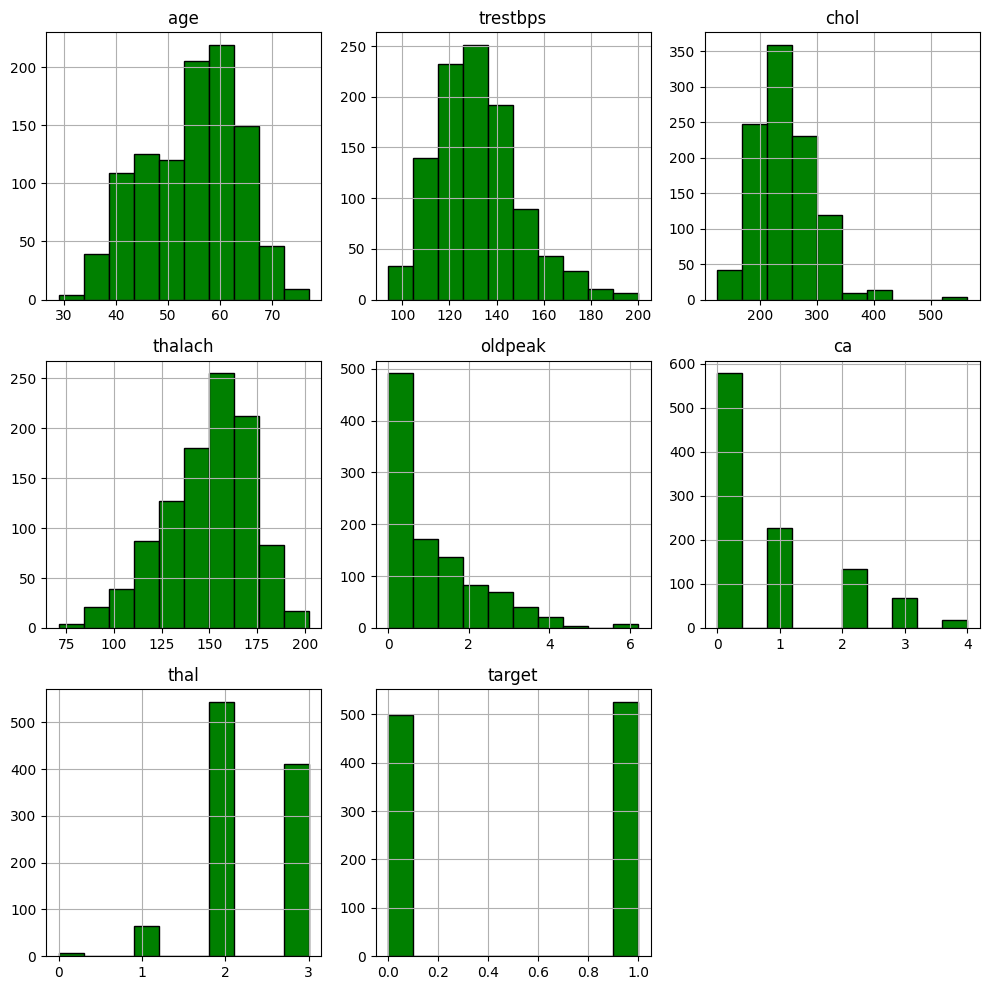

In [11]:
#histogram
import matplotlib.pyplot as plt
numerical.hist(figsize=(10,10),color='Green',edgecolor='Black',bins=10)
plt.tight_layout()
plt.show()

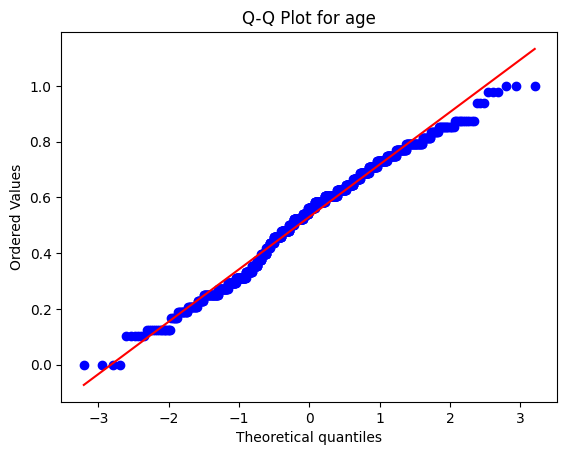

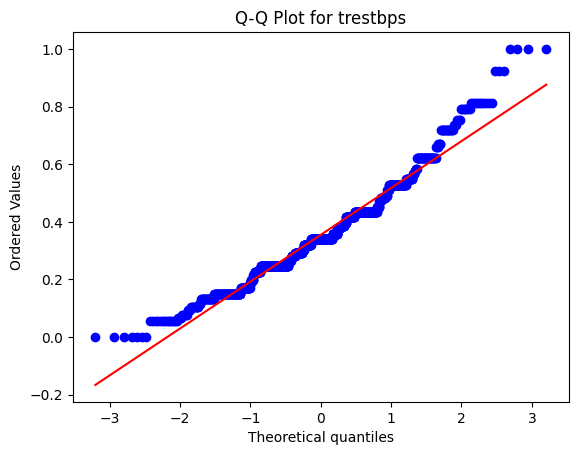

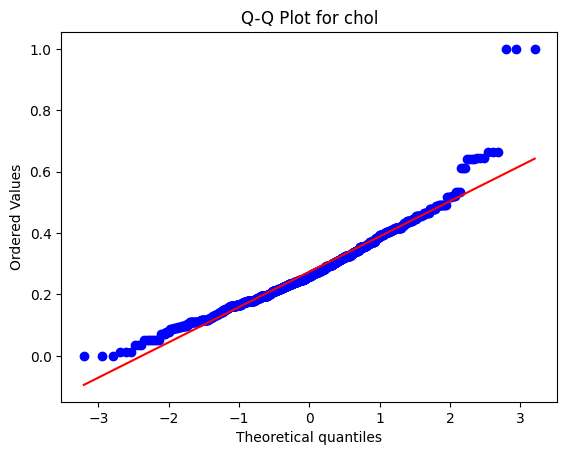

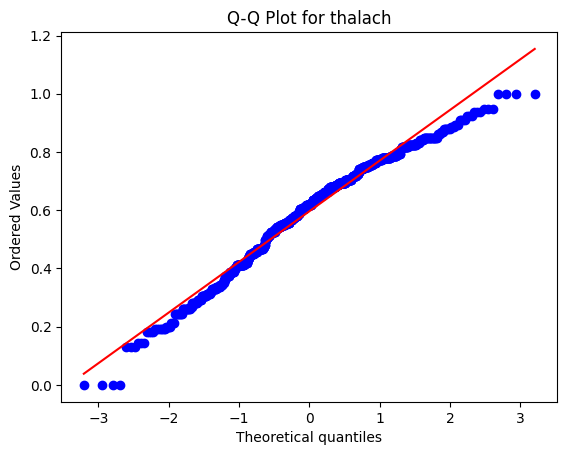

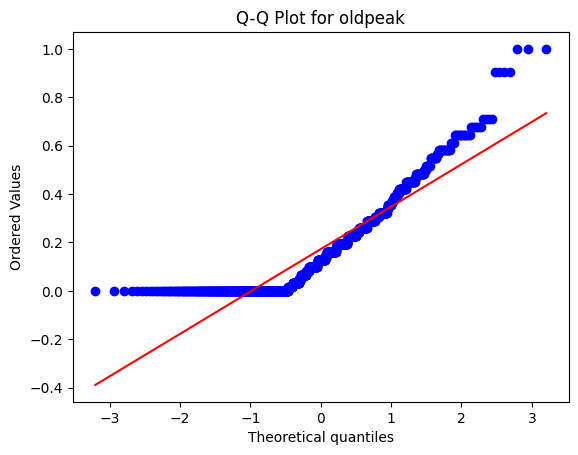

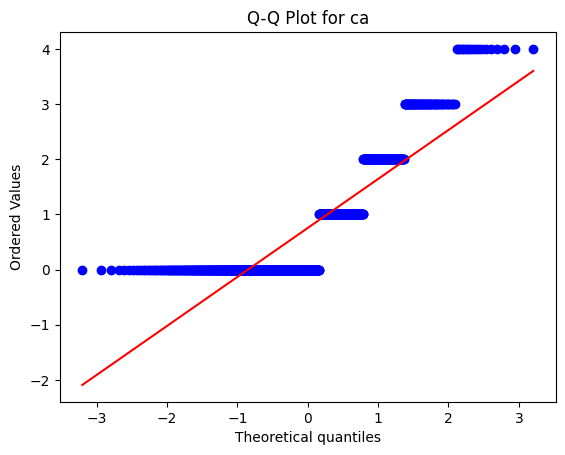

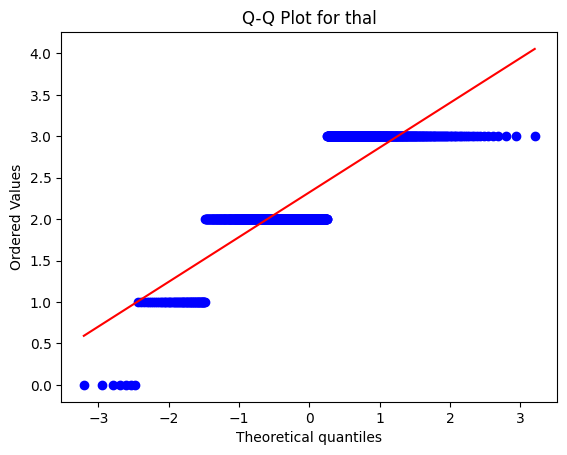

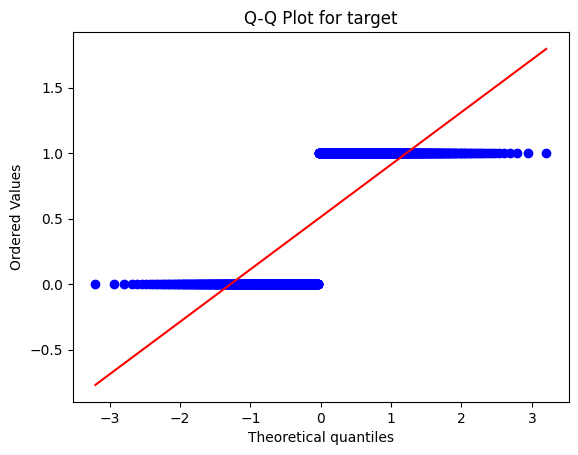

In [14]:

for col in numerical:
    stats.probplot(df[col], dist="norm", plot=plt) #col is data
    plt.title(f'Q-Q Plot for {col}')
    plt.show()


#if data is normally distributed → Points will fall along the 45-degree line.

In [16]:
#to evaluate normality of data
#Shapiro-Wilk Test
for col in numerical:
    stat,p=stats.shapiro(df[col])
    print(f"shapiro test for {col}:Statistic:{stat:.3f},p value:{p:.3f}")
    if p>0.05:
        print(f'--> {col} looks Normally Distributed (Fail to Reject H0)')
    else:
        print(f'--> {col} is NOT Normally Distributed (Reject H0)')

shapiro test for age:Statistic:0.984,p value:0.000
--> age is NOT Normally Distributed (Reject H0)
shapiro test for trestbps:Statistic:0.963,p value:0.000
--> trestbps is NOT Normally Distributed (Reject H0)
shapiro test for chol:Statistic:0.950,p value:0.000
--> chol is NOT Normally Distributed (Reject H0)
shapiro test for thalach:Statistic:0.977,p value:0.000
--> thalach is NOT Normally Distributed (Reject H0)
shapiro test for oldpeak:Statistic:0.850,p value:0.000
--> oldpeak is NOT Normally Distributed (Reject H0)
shapiro test for ca:Statistic:0.738,p value:0.000
--> ca is NOT Normally Distributed (Reject H0)
shapiro test for thal:Statistic:0.754,p value:0.000
--> thal is NOT Normally Distributed (Reject H0)
shapiro test for target:Statistic:0.636,p value:0.000
--> target is NOT Normally Distributed (Reject H0)


In [17]:
#Kolmogorov-Smirnov Test
for col in numerical:
    data_good=(df[col]-df[col].mean())/df[col].std()
    stat,p=stats.kstest(data_good,'norm')
    print(f'the kolmogorov smirnov test for {col}:Statistic={stat:.3f},pvalue={p:.3f}')
    if p > 0.05:
        print(f'--> {col} looks Normally Distributed (Fail to Reject H0)')
    else:
        print(f'--> {col} is NOT Normally Distributed (Reject H0)')

the kolmogorov smirnov test for age:Statistic=0.080,pvalue=0.000
--> age is NOT Normally Distributed (Reject H0)
the kolmogorov smirnov test for trestbps:Statistic=0.104,pvalue=0.000
--> trestbps is NOT Normally Distributed (Reject H0)
the kolmogorov smirnov test for chol:Statistic=0.056,pvalue=0.003
--> chol is NOT Normally Distributed (Reject H0)
the kolmogorov smirnov test for thalach:Statistic=0.069,pvalue=0.000
--> thalach is NOT Normally Distributed (Reject H0)
the kolmogorov smirnov test for oldpeak:Statistic=0.181,pvalue=0.000
--> oldpeak is NOT Normally Distributed (Reject H0)
the kolmogorov smirnov test for ca:Statistic=0.332,pvalue=0.000
--> ca is NOT Normally Distributed (Reject H0)
the kolmogorov smirnov test for thal:Statistic=0.299,pvalue=0.000
--> thal is NOT Normally Distributed (Reject H0)
the kolmogorov smirnov test for target:Statistic=0.348,pvalue=0.000
--> target is NOT Normally Distributed (Reject H0)


In [ ]:
#if data not normal apply tranformation techniques
#for all positive and not null data use box-cox or lagarithmic
#for data with neg values use yeo-johnson transformation
#boxcox
#df['chol_boxcox'],fitted_lambda=stats.boxcox(df['age'])
#print(f"lambda for box cox :{fitted_lambda}")
#log transformation 
#df['chol_log'] = np.log(df['chol'])

In [ ]:
for col in numerical:
    print(col)
    print(df[col][df[col] <= 0])
#all data has zero values so use yeo johnson approach


age
60     0.0
64     0.0
118    0.0
668    0.0
Name: age, dtype: float64
trestbps
173    0.0
223    0.0
301    0.0
558    0.0
704    0.0
732    0.0
808    0.0
Name: trestbps, dtype: float64
chol
101    0.0
336    0.0
475    0.0
Name: chol, dtype: float64
thalach
267    0.0
296    0.0
378    0.0
559    0.0
Name: thalach, dtype: float64
oldpeak
3       0.0
19      0.0
23      0.0
24      0.0
27      0.0
       ... 
1009    0.0
1011    0.0
1018    0.0
1020    0.0
1023    0.0
Name: oldpeak, Length: 329, dtype: float64
ca
1       0
2       0
5       0
8       0
10      0
       ..
1014    0
1018    0
1019    0
1020    0
1023    0
Name: ca, Length: 578, dtype: int64
thal
14     0
319    0
329    0
359    0
686    0
734    0
893    0
Name: thal, dtype: int64
target
0       0
1       0
2       0
3       0
4       0
       ..
1017    0
1018    0
1021    0
1022    0
1024    0
Name: target, Length: 499, dtype: int64


In [ ]:
#yeo johnson approach
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer(method='yeo-johnson')
df['age_yeojohnson']=pt.fit_transform(df[['age']])
print(df[['age','age_yeojohnson']].head())
#apply before doing min max scaling

        age  age_yeojohnson
0  0.479167       -0.315639
1  0.500000       -0.206343
2  0.854167        1.826021
3  0.666667        0.709425
4  0.687500        0.829016


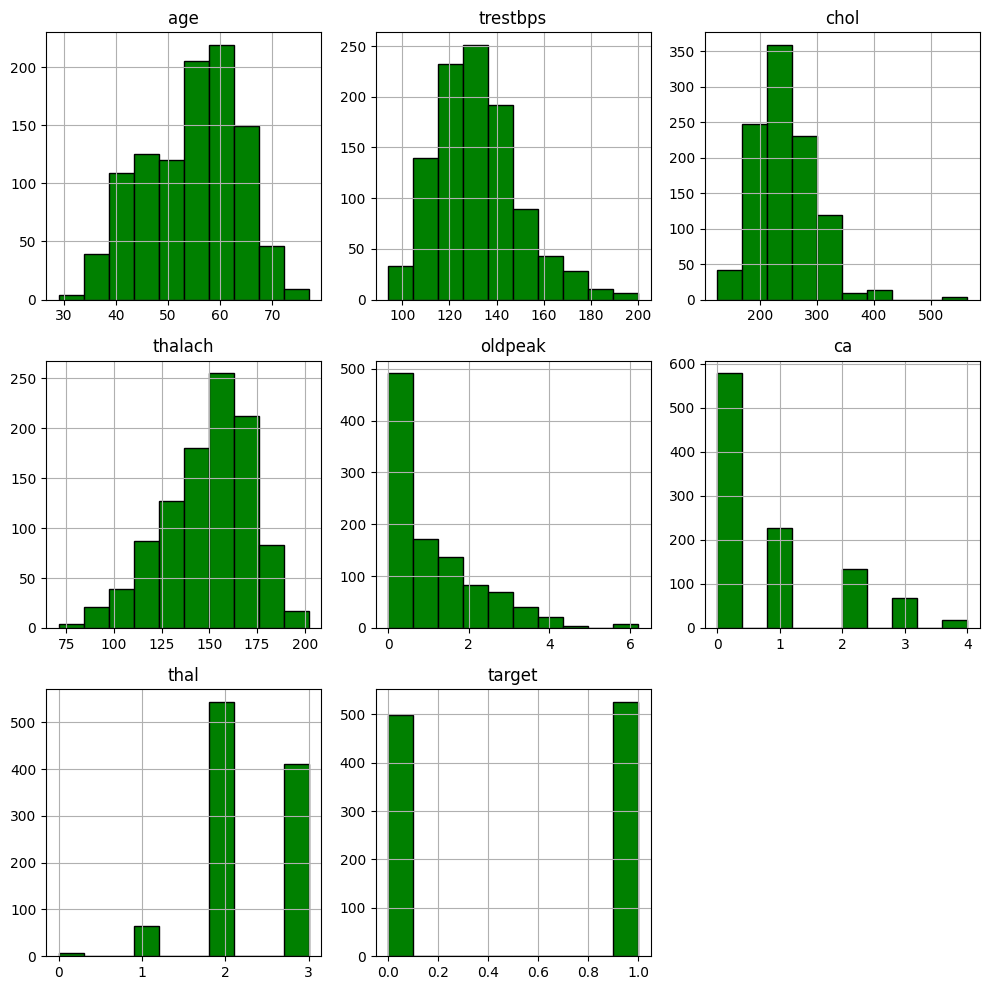

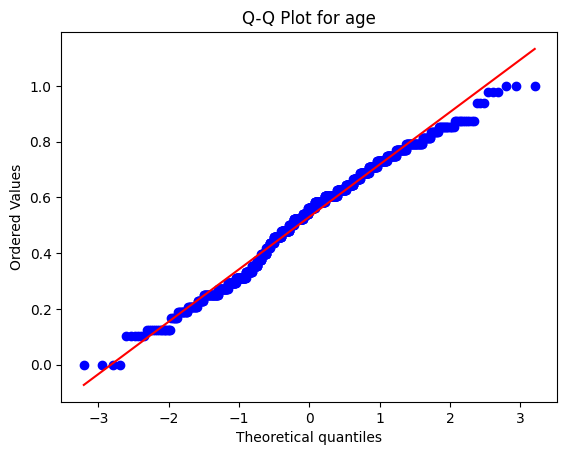

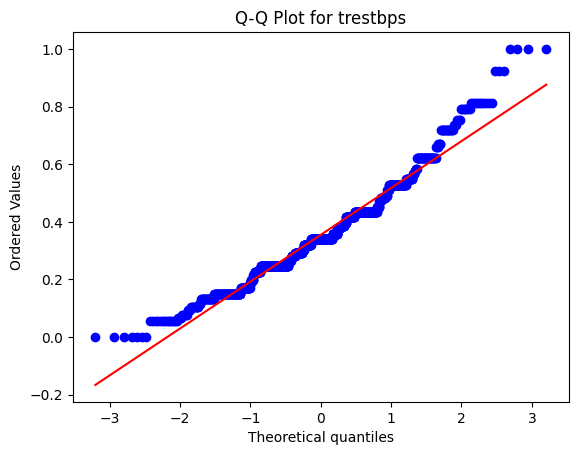

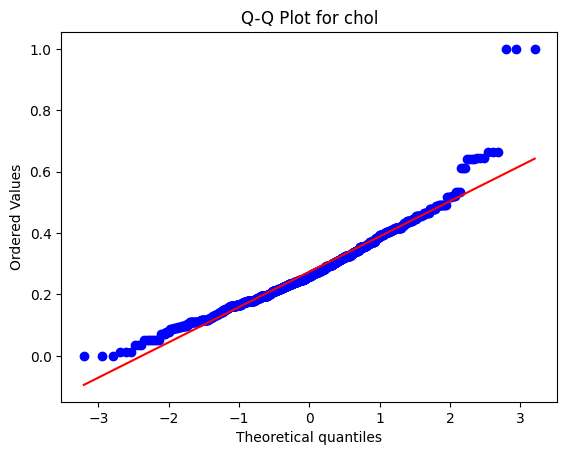

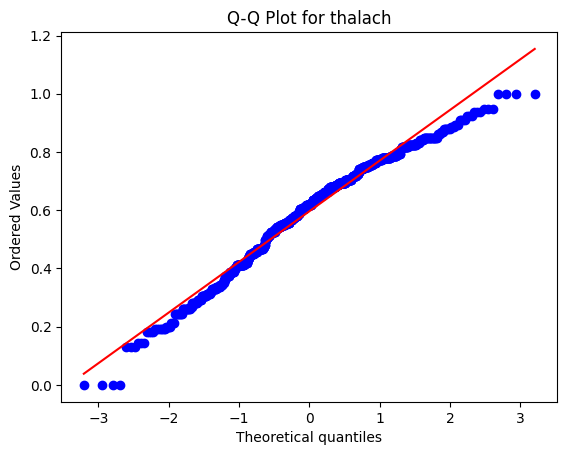

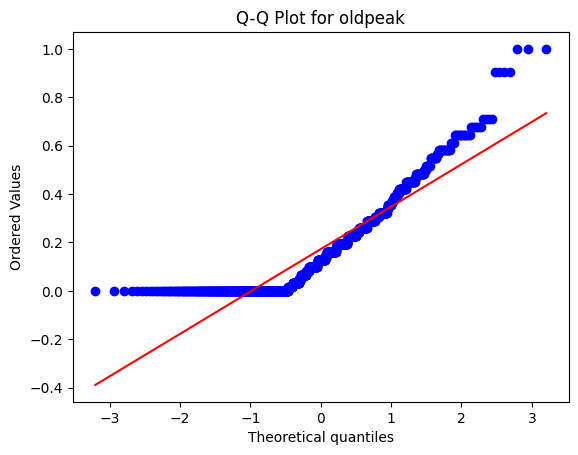

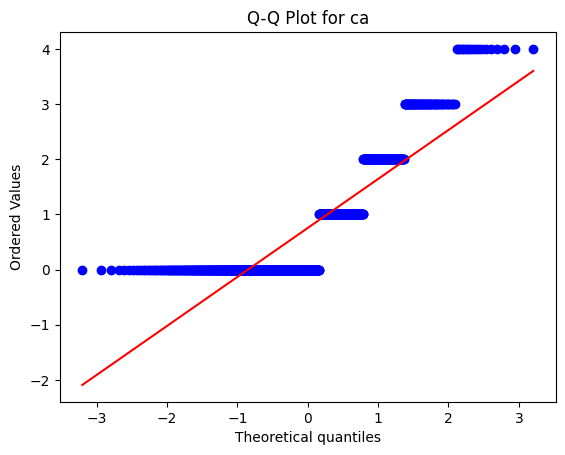

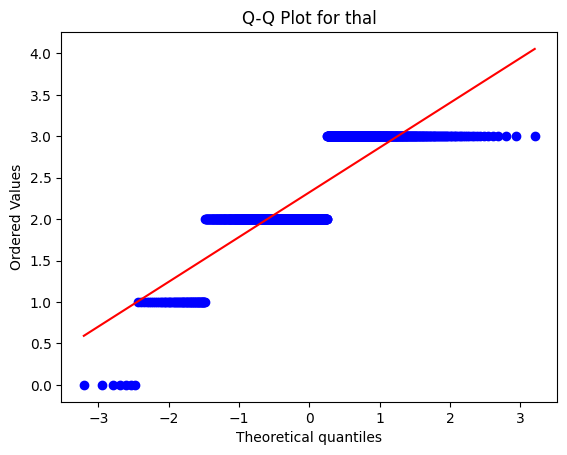

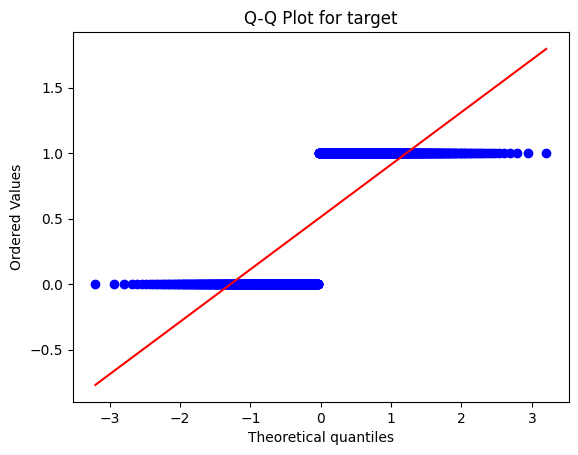

shapiro test for age:Statistic:0.984,p value:0.000
--> age is NOT Normally Distributed (Reject H0)
shapiro test for trestbps:Statistic:0.963,p value:0.000
--> trestbps is NOT Normally Distributed (Reject H0)
shapiro test for chol:Statistic:0.950,p value:0.000
--> chol is NOT Normally Distributed (Reject H0)
shapiro test for thalach:Statistic:0.977,p value:0.000
--> thalach is NOT Normally Distributed (Reject H0)
shapiro test for oldpeak:Statistic:0.850,p value:0.000
--> oldpeak is NOT Normally Distributed (Reject H0)
shapiro test for ca:Statistic:0.738,p value:0.000
--> ca is NOT Normally Distributed (Reject H0)
shapiro test for thal:Statistic:0.754,p value:0.000
--> thal is NOT Normally Distributed (Reject H0)
shapiro test for target:Statistic:0.636,p value:0.000
--> target is NOT Normally Distributed (Reject H0)
age
60     0.0
64     0.0
118    0.0
668    0.0
Name: age, dtype: float64
trestbps
173    0.0
223    0.0
301    0.0
558    0.0
704    0.0
732    0.0
808    0.0
Name: trestbps

In [31]:
#after verifying normalization again do step 2,3
#histogram
import matplotlib.pyplot as plt
numerical.hist(figsize=(10,10),color='Green',edgecolor='Black',bins=10)
plt.tight_layout()
plt.show()
for col in numerical:
    stats.probplot(df[col], dist="norm", plot=plt) #col is data
    plt.title(f'Q-Q Plot for {col}')
    plt.show()
for col in numerical:
    stat,p=stats.shapiro(df[col])
    print(f"shapiro test for {col}:Statistic:{stat:.3f},p value:{p:.3f}")
    if p>0.05:
        print(f'--> {col} looks Normally Distributed (Fail to Reject H0)')
    else:
        print(f'--> {col} is NOT Normally Distributed (Reject H0)')
for col in numerical:
    print(col)
    print(df[col][df[col] <= 0])
#all data has zero values so use yeo johnson approach

#if data is normally distributed → Points will fall along the 45-degree line.


In [ ]:
#still not normalized ?
#Yeo-Johnson is not a magic bullet — It helps approximate normality, but not all real-world data can become perfectly normal.

#Some features might have intrinsic skewness/outliers that can't be fixed with transformations.

#The Shapiro-Wilk test is very sensitive — With large sample sizes, even tiny deviations from normality can make it reject H0.

#Q-Q plots can exaggerate minor deviations especially at the tails.

Discuss the findings and implications of the data's distribution for further analysis or modeling.
The distribution analysis revealed that many features are not normally distributed, with some containing zero values, making Box-Cox unsuitable. Applying Yeo-Johnson transformations improved the distribution but did not achieve perfect normality, as confirmed by Q-Q plots and Shapiro-Wilk tests. For further analysis, linear models would require these transformations to handle skewness, while tree-based models like Random Forest or XGBoost can handle raw data without issue. For statistical tests, non-parametric methods are more appropriate due to the persistent deviation from normality. Proper scaling (Min-Max or StandardScaler) remains essential for models sensitive to feature magnitude.